# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

Fornecemos alguns comentários para guiar sua linha de raciocínio enquanto você trabalha neste projeto. Entretanto, certifique-se de remover todos os comentários entre colchetes antes de enviar o projeto.

Antes de começar a análise dos dados, explique com suas próprias palavras o propósito do projeto e as ações que planeja realizar.

Tenha em mente que estudar, modificar e analisar dados é um processo iterativo. É normal retornar a etapas anteriores e corrigir/expandir algo para permitir as próximas etapas.

## Inicialização

In [1]:
import pandas as pd
import numpy as np
from scipy import stats as st 
from matplotlib import pyplot as plt
import seaborn as sns # Carregando todas as bibliotecas



## Carregue os dados

In [2]:
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')
# Carregue os arquivos de dados em diferentes DataFrames



## Prepare os dados

Os dados deste projeto estão divididos em várias tabelas. Explore cada uma para obter uma compreensão inicial dos dados. Faça correções em cada tabela, se necessário.

## Planos

In [ ]:
plans.info() # Imprima informações gerais/resumo sobre o DataFrame dos planos



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
print(plans.head())# Imprima uma amostra de dados dos planos



   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?

O Dataframe contém 2 linhas e 8 colunas, aparecem também quantidades como: minutos,mensagens,GB.
Os dados dos Planos estão corretos e contém informações consistentes.

## Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [5]:
# Os dados não apresentam nada há ser corrigido, tudo esta consistente e bem montado.

## Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [6]:
print(plans.duplicated())

0    False
1    False
dtype: bool


## Usuários

In [7]:
users.info()# Imprima informações gerais/resumo sobre o DataFrame dos usuários



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [8]:
users.head()# Imprima uma amostra de dados dos usuários



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?

Em boa parte dos dados consta certo como user id, primeiro nome, último nome, idade, cidade, e os planos contratados. Porém na parte de churn_date temos valores ausentes ou que não cancelaram o plano. 
reg_date e churn_date estão como object, mas representam datas e deveriam ser convertidos para Datetime.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [9]:
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [10]:
users['churn'] = users['churn_date'].notna().astype(int)
users['churn'].head()

0    0
1    0
2    0
3    0
4    0
Name: churn, dtype: int64

## Chamadas

In [11]:
calls.info()# Imprima informações gerais/resumo sobre o DataFrame das chamadas



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [12]:
calls.head() # Imprima uma amostra de dados das chamadas



,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?

Nesse Dataframe verificamos que a entrada calls tem registro de 137.735 e 4 colunas.
a coluna call_date esta definido como objeto, embora seja datas.
A duração da chamada deve ser convertida para números inteiros?



### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [13]:
calls['call_date'] = pd.to_datetime(calls['call_date'])
calls.info()
calls.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

## Mensagens

In [14]:
messages.info()# Imprima informações gerais/resumo sobre o DataFrame das mensagens



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [15]:
messages.head()# Imprima uma amostra dos dados das mensagens



,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?

Nesse Dataframe verificamos que temos 76.051 registros e 3 colunas.
Não verificamos nenhum valor ausente.
message_date dever ser convertido para uma data usando datetime, esta como object.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [16]:
messages['message_date']=pd.to_datetime(messages['message_date'])
messages.info()
messages.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

## Internet

In [17]:
internet.info()# Imprima informações gerais/resumo sobre o DataFrame da internet



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [18]:
internet.head()#  Imprima uma amostra de dados para o tráfego da internet



,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?

Verificamos nesse Dataframe que constam 104.825 rgistros.
Não consta nenhum valor ausente porém session_date esta como object, precisamos muda-lo para data e deixar o dado certo. O restante do dado está correto.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [19]:
internet['session_date']= pd.to_datetime(internet['session_date'])
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [20]:
internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


## Estude as condições dos planos

É fundamental entender como os planos funcionam, ou seja, como as cobranças dos usuários são feitas com base na assinatura. Sugerimos imprimir as informações sobre os planos para visualizar novamente as condições.

In [21]:
plans.info()
plans.head()# Imprima as condições dos planos e certifique-se de que elas fazem sentido para você



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Agregue os dados por usuário

[Agora, como os dados estão limpos, os agregue por usuário e por período para ter apenas um registro dessas informações. Isso vai facilitar muito as próximas análises.]

In [22]:
calls['call_date'] = pd.to_datetime(calls['call_date'])
calls['month'] = calls['call_date'].dt.month
calls_count_per_month= calls.groupby(['user_id', 'month'])['id'].count().reset_index()
calls_count_per_month.head()# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.



,user_id,month,id
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64


In [23]:
calls['month'] = calls['call_date'].dt.month
minutes_per_month= calls.groupby(['user_id', 'month'])['duration'].sum().reset_index()
minutes_per_month.head()# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.



,user_id,month,duration
0,1000,12,116.83
1,1001,8,171.14
2,1001,9,297.69
3,1001,10,374.11
4,1001,11,404.59


In [24]:
messages['message_date'] = pd.to_datetime(messages['message_date'])
messages['month'] = messages['message_date'].dt.month
messages_per_month= messages.groupby(['user_id', 'month'])['id'].count().reset_index()
messages.head()# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.



,id,user_id,message_date,month
0,1000_125,1000,2018-12-27,12
1,1000_160,1000,2018-12-31,12
2,1000_223,1000,2018-12-31,12
3,1000_251,1000,2018-12-27,12
4,1000_255,1000,2018-12-26,12


In [25]:
internet['session_date'] = pd.to_datetime(internet['session_date'])
internet['month'] = internet['session_date'].dt.month
internet_per_month = internet.groupby(['user_id','month']) ['mb_used'].sum().reset_index()
internet_per_month.head()# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.



,user_id,month,mb_used
0,1000,12,1901.47
1,1001,8,6919.15
2,1001,9,13314.82
3,1001,10,22330.49
4,1001,11,18504.30


[Coloque os dados agregados em um DataFrame para que cada registro nele represente o que cada usuário consumiu em um determinado mês.]

In [26]:
monthly_usage = calls_count_per_month.merge(minutes_per_month,
                                             on=['user_id','month'],
                                             how='outer'
                                            )
monthly_usage.head()


monthly_usage= monthly_usage.merge(messages_per_month,
                                   on=['user_id','month'],
                                   how='outer'
                                  )
monthly_usage.head()

monthly_usage = monthly_usage.merge(internet_per_month,
                                    on=['user_id','month'],
                                    how='outer'
                                   )
monthly_usage.head()

monthly_usage= monthly_usage.rename(columns={'id_x':'calls_count',
                                                   'id_y':'messages_count'})
monthly_usage.head()# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month



,user_id,month,calls_count,duration,messages_count,mb_used
0,1000,12,16.0,116.83,11.0,1901.47
1,1001,8,27.0,171.14,30.0,6919.15
2,1001,9,49.0,297.69,44.0,13314.82
3,1001,10,65.0,374.11,53.0,22330.49
4,1001,11,64.0,404.59,36.0,18504.30


In [27]:
monthly_usage = monthly_usage.rename(columns={'duration':'total_minutes',
                                              'mb_used':'total_mb'})
monthly_usage.head()

plans_per_month= users[['user_id', 'plan']]
monthly_usage = monthly_usage.merge(plans_per_month,
                                    on=['user_id'],
                                    how='outer'
                                   )
monthly_usage= monthly_usage.fillna(0)
monthly_usage.head()# Adicione as informações sobre o plano



,user_id,month,calls_count,total_minutes,messages_count,total_mb,plan
0,1000,12.0,16.0,116.83,11.0,1901.47,ultimate
1,1001,8.0,27.0,171.14,30.0,6919.15,surf
2,1001,9.0,49.0,297.69,44.0,13314.82,surf
3,1001,10.0,65.0,374.11,53.0,22330.49,surf
4,1001,11.0,64.0,404.59,36.0,18504.30,surf


In [28]:
monthly_usage.isna().sum()

user_id           0
month             0
calls_count       0
total_minutes     0
messages_count    0
total_mb          0
plan              0
dtype: int64

[Calcule a receita mensal para cada usuário: subtraia o limite gratuito do pacote do número total de chamadas, mensagens de texto e dados; multiplique o resultado pelo valor do plano; adicione o preço mensal dependendo do plano. Importante: isso talvez não seja tão simples e necessite de várias linhas, considerando as condições do plano. Portanto, não se preocupe se você passar algum tempo nesta etapa.]

In [29]:
monthly_usage_with_plans = monthly_usage.merge(plans, left_on='plan', right_on='plan_name')
monthly_usage['revenue'] = (
    monthly_usage_with_plans['usd_monthly_pay'] +
    np.maximum(0, monthly_usage_with_plans['total_minutes'] - monthly_usage_with_plans['minutes_included']) * monthly_usage_with_plans['usd_per_minute'] +
    np.maximum(0, monthly_usage_with_plans['messages_count'] - monthly_usage_with_plans['messages_included']) * monthly_usage_with_plans['usd_per_message'] +
    np.maximum(0, (monthly_usage_with_plans['total_mb'] - monthly_usage_with_plans['mb_per_month_included']) / 1024) * monthly_usage_with_plans['usd_per_gb']
)
print(monthly_usage_with_plans)

      user_id  month  calls_count  total_minutes  messages_count  total_mb  \
0        1000   12.0         16.0         116.83            11.0   1901.47   
1        1006   11.0          2.0           9.32            15.0   2068.37   
2        1006   12.0          9.0          54.79           139.0  32118.82   
3        1008   10.0         71.0         450.21            21.0  17106.99   
4        1008   11.0         63.0         422.81            37.0  23676.72   
...       ...    ...          ...            ...             ...       ...   
2298     1143    0.0          0.0           0.00             0.0      0.00   
2299     1307    0.0          0.0           0.00             0.0      0.00   
2300     1319    0.0          0.0           0.00             0.0      0.00   
2301     1378    0.0          0.0           0.00             0.0      0.00   
2302     1473    0.0          0.0           0.00             0.0      0.00   

          plan  messages_included  mb_per_month_included  minut

## Estude o comportamento do usuário

Calcule algumas estatísticas descritivas úteis para os dados agregados, o que costuma revelar uma imagem geral capturada pelos dados. Desenhe gráficos úteis para ajudar na compreensão. Já que a tarefa principal é comparar os planos e decidir qual é mais rentável, as estatísticas e os gráficos devem ser calculados por plano.]

Existem dicas relevantes nos comentários para as chamadas. Essas dicas não foram fornecidas para as mensagens e internet, mas o princípio do estudo estatístico é o mesmo em todos os casos.

### Chamadas

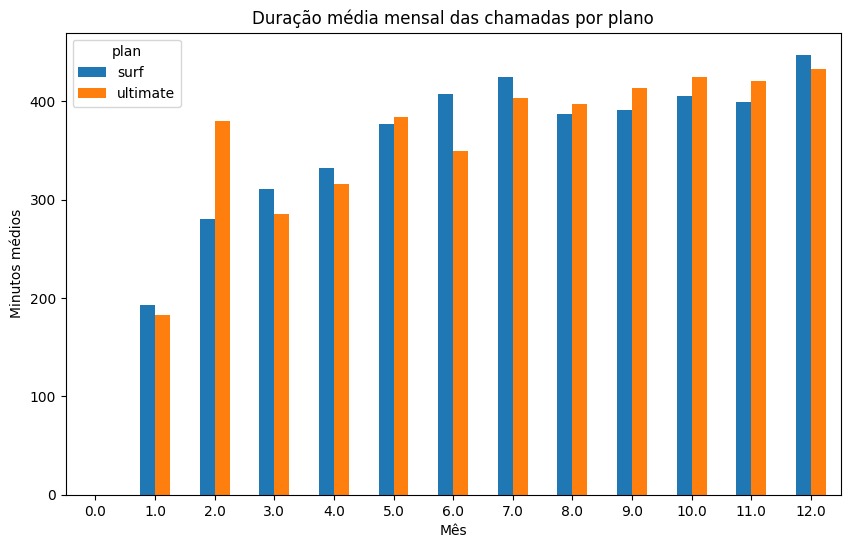

In [30]:
calls_mean = monthly_usage.groupby(['plan', 'month'])['total_minutes'].mean().reset_index()
calls_pivot = calls_mean.pivot(index= 'month', columns= 'plan', values= 'total_minutes')
calls_pivot.plot(kind= 'bar',figsize= (10,6))
plt.title('Duração média mensal das chamadas por plano')
plt.xlabel('Mês')
plt.ylabel('Minutos médios')# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.
plt.xticks(rotation=0)
plt.show()


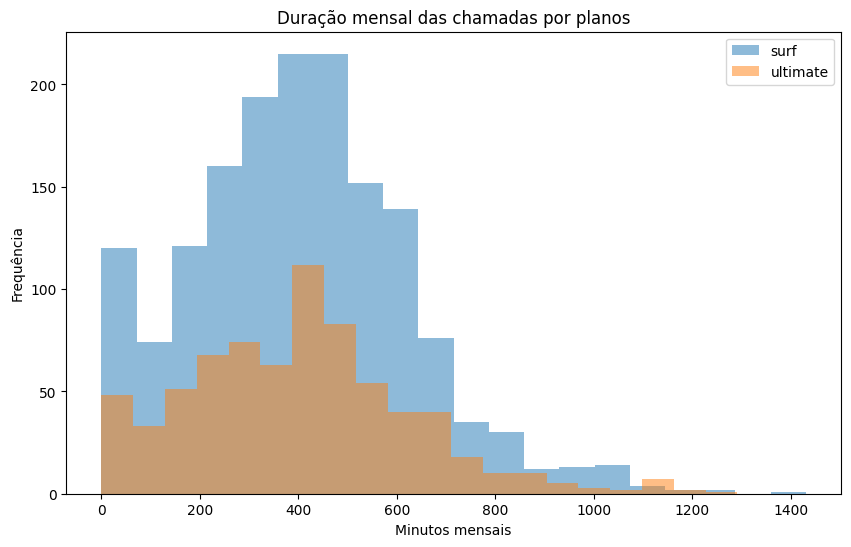

In [31]:
monthly_usage.groupby(['plan', 'month'])['total_minutes'].mean()

surf_minutes= monthly_usage[monthly_usage['plan']== 'surf']['total_minutes']# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.
ultimate_minutes= monthly_usage[monthly_usage['plan']=='ultimate']['total_minutes']

plt.figure(figsize=(10,6))
plt.hist(surf_minutes, bins=20, alpha=0.5, label= 'surf')
plt.hist(ultimate_minutes, bins= 20, alpha= 0.5, label= 'ultimate')

plt.title('Duração mensal das chamadas por planos')
plt.xlabel('Minutos mensais')
plt.ylabel('Frequência')
plt.legend()
plt.show()


Calcule a média e a variância da duração das chamadas para refletir se os usuários de cada plano possuem comportamentos diferentes sobre as chamadas.

In [32]:
mean_calls = monthly_usage.groupby('plan')['total_minutes'].mean()
var_calls = monthly_usage.groupby('plan')['total_minutes'].var()

print("Média de minutos por plano:")
print(mean_calls)
print("\nVariância de minutos por plano:")
print(var_calls)# Calcule a média e a variância da duração mensal das chamadas



Média de minutos por plano:
plan
surf        403.224345
ultimate    403.948923
Name: total_minutes, dtype: float64

Variância de minutos por plano:
plan
surf        49568.849927
ultimate    52263.047679
Name: total_minutes, dtype: float64


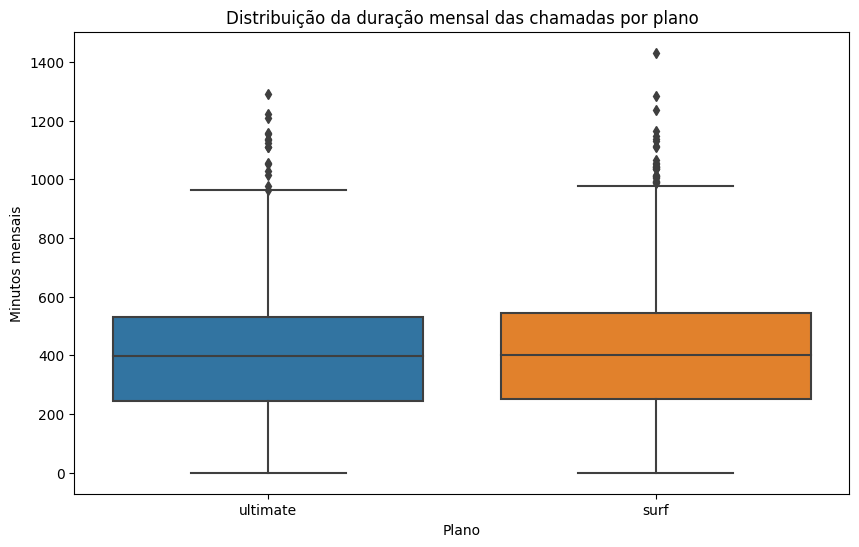

In [33]:
plt.figure(figsize=(10,6))
sns.boxplot(data= monthly_usage, x='plan', y='total_minutes')
plt.title('Distribuição da duração mensal das chamadas por plano')
plt.xlabel('Plano')
plt.ylabel('Minutos mensais')
plt.show()# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas



Formule conclusões sobre como os usuários se comportam em termos de chamadas. O comportamento é diferente dependendo do plano?

Nesse diagrama de caixa podemos ver que a duração mensal são bem parecidas, tanto em surf como para ultimate.
A mediana do plano Surf é um pouco maior o que quer dizer que as pessoas usam um pouco mais de minutos.
Médias: Surf (412.10 min) vs Ultimate (410.18 min) - praticamente iguais

### Mensagens

In [34]:
mean_messages = monthly_usage.groupby('plan')['messages_count'].mean()
var_messages= monthly_usage.groupby('plan')['messages_count'].var() #Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês
print(mean_messages)
print(var_messages)# Calcule a média e a variância da duração mensal das chamadas


plan
surf        31.041165
ultimate    37.343923
Name: messages_count, dtype: float64
plan
surf        1126.118076
ultimate    1209.827612
Name: messages_count, dtype: float64


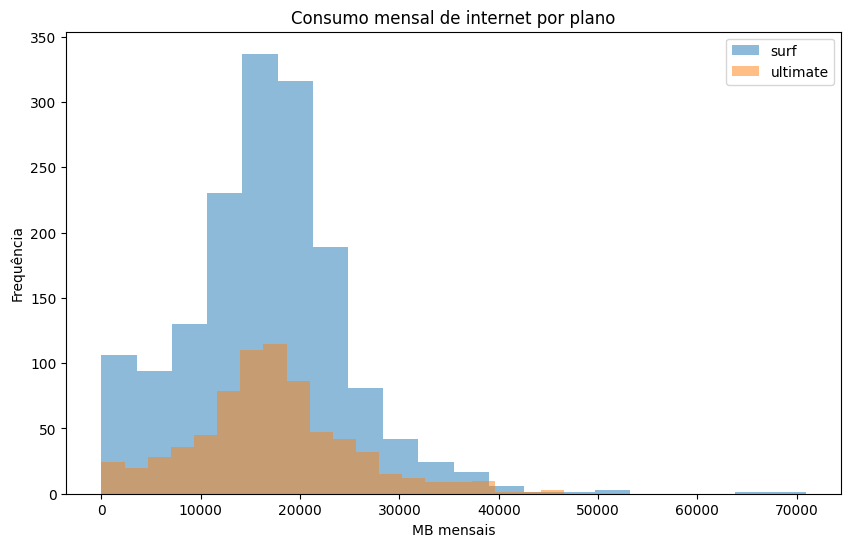

Média de MB por plano:
plan
surf        16495.364110
ultimate    17119.590856
Name: total_mb, dtype: float64

Variância de MB por plano:
plan
surf        6.501076e+07
ultimate    6.294168e+07
Name: total_mb, dtype: float64


In [35]:
surf_internet = monthly_usage[monthly_usage['plan'] == 'surf']['total_mb']
ultimate_internet = monthly_usage[monthly_usage['plan'] == 'ultimate']['total_mb']
plt.figure(figsize=(10,6))
plt.hist(surf_internet, bins=20, alpha=0.5, label='surf')
plt.hist(ultimate_internet, bins=20, alpha=0.5, label='ultimate')
plt.title('Consumo mensal de internet por plano')
plt.xlabel('MB mensais')
plt.ylabel('Frequência')
plt.legend()
plt.show()# Compare a quantidade de tráfego de internet consumido pelos usuários por plano
mean_internet = monthly_usage.groupby('plan')['total_mb'].mean()
var_internet = monthly_usage.groupby('plan')['total_mb'].var()
print("Média de MB por plano:")
print(mean_internet)
print("\nVariância de MB por plano:")
print(var_internet)


### Internet

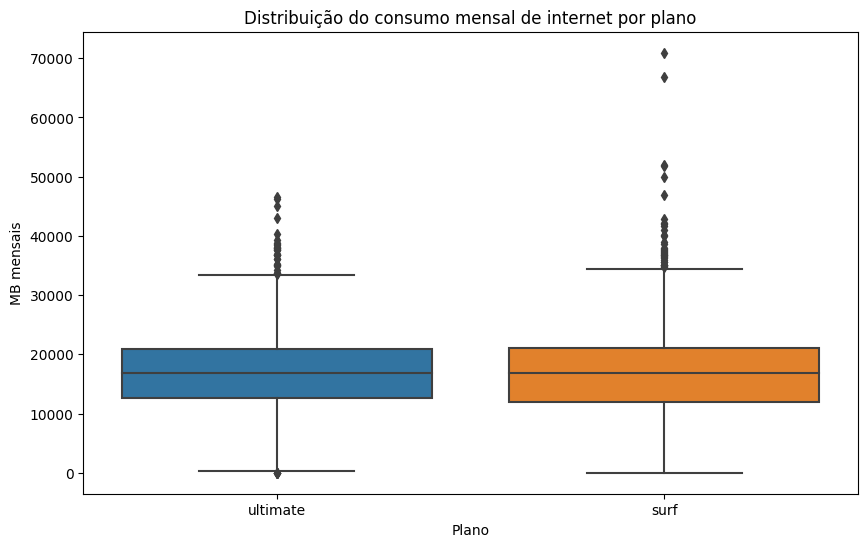

In [36]:
plt.figure(figsize=(10,6))
sns.boxplot(data=monthly_usage, x='plan', y='total_mb')
plt.title('Distribuição do consumo mensal de internet por plano')
plt.xlabel('Plano')
plt.ylabel('MB mensais')
plt.show()

In [37]:
# A diferença dos valores médios não é muito grande.

In [38]:
# A variância do consumo também é semelhante entre os dois planos, indicando que o comportamento dos usuários em relação ao uso de internet é bem parecido.

Formule conclusões sobre como os usuários tendem a consumir o tráfego da internet. O comportamento é diferente dependendo do plano?

## Receita

Da mesma forma que você estudou o comportamento dos usuários, descreva estatisticamente as receitas dos planos.

In [39]:
mean_revenue= monthly_usage.groupby('plan')['revenue'].mean()
var_revenue= monthly_usage.groupby('plan')['revenue'].var()
print(mean_revenue)
print(var_revenue)

plan
surf        61.260055
ultimate    63.145128
Name: revenue, dtype: float64
plan
surf        2000.488361
ultimate    2190.011029
Name: revenue, dtype: float64


In [40]:
median_revenue= monthly_usage.groupby('plan')['revenue'].median()
print(median_revenue)

plan
surf        70.0
ultimate    70.0
Name: revenue, dtype: float64


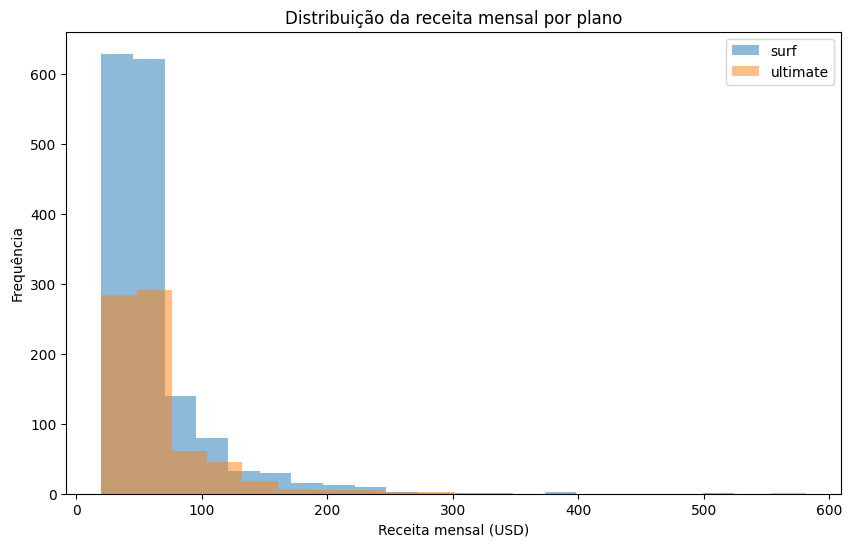

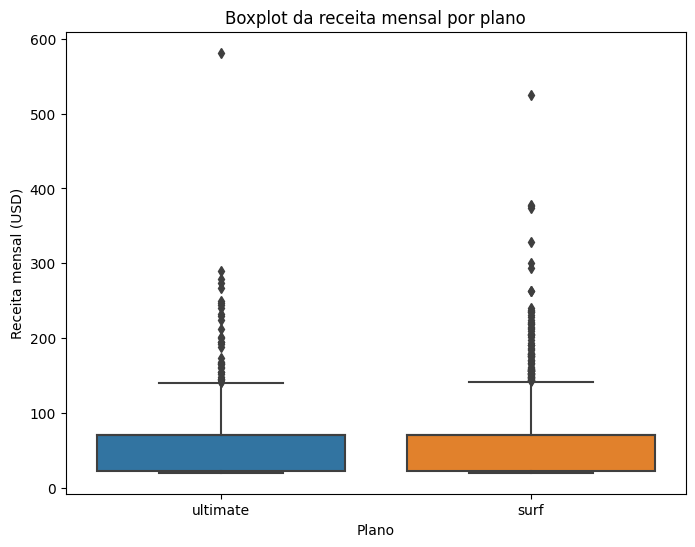

In [41]:

surf_revenue = monthly_usage[monthly_usage['plan'] == 'surf']['revenue']
ultimate_revenue = monthly_usage[monthly_usage['plan'] == 'ultimate']['revenue']

plt.figure(figsize=(10,6))

plt.hist(surf_revenue, bins=20, alpha=0.5, label='surf')
plt.hist(ultimate_revenue, bins=20, alpha=0.5, label='ultimate')

plt.title('Distribuição da receita mensal por plano')
plt.xlabel('Receita mensal (USD)')
plt.ylabel('Frequência')
plt.legend()

plt.show()

plt.figure(figsize=(8,6))

sns.boxplot(x='plan', y='revenue', data=monthly_usage)

plt.title('Boxplot da receita mensal por plano')
plt.xlabel('Plano')
plt.ylabel('Receita mensal (USD)')

plt.show()

## Teste hipóteses estatísticas

[Teste a hipótese de que a receita média dos usuários dos planos Ultimate e Surf são diferentes.]

[Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.]

H0: A receita média dos planos Surf e Ultimate são iguais
H1: A receita média dos planos Surf e Ultimate são diferentes

Variância Surf: 2000.4883614217424
Variância Ultimate: 2190.0110289144845
Razão das variâncias: 0.9134604049977401
Variâncias similares? True

Estatística t: -0.9253452502362123
p-value: 0.35488338275844644
Alpha: 0.05

Não rejeitamos H0: Não há evidência de diferença significativa


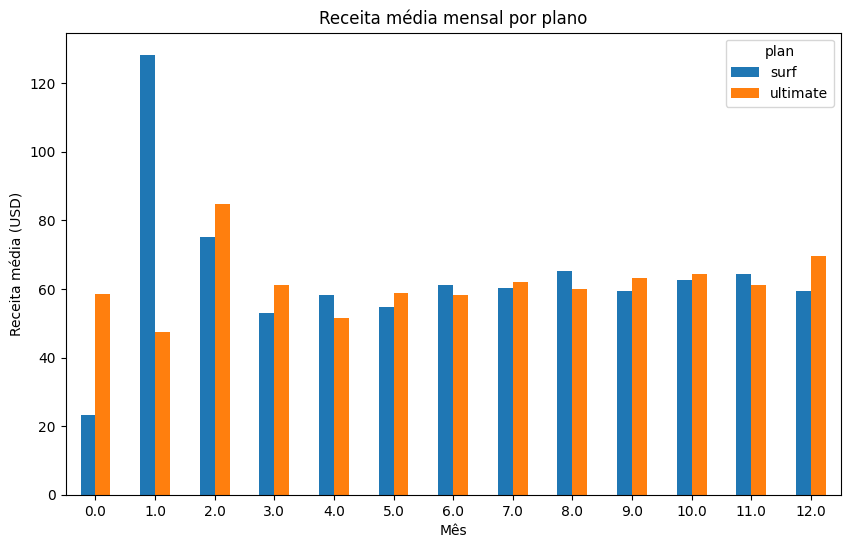

In [42]:
print("H0: A receita média dos planos Surf e Ultimate são iguais")
print("H1: A receita média dos planos Surf e Ultimate são diferentes")
print()

# Separar os dados por plano
surf = monthly_usage[monthly_usage['plan'] == 'surf']['revenue'].dropna()
ultimate = monthly_usage[monthly_usage['plan'] == 'ultimate']['revenue'].dropna()

# Avaliar as variâncias (versão simples)
var_surf = surf.var()
var_ultimate = ultimate.var()
print("Variância Surf:", var_surf)
print("Variância Ultimate:", var_ultimate)


ratio_var = var_surf / var_ultimate
equal_var = ratio_var < 4 and ratio_var > 0.25
print("Razão das variâncias:", ratio_var)
print("Variâncias similares?", equal_var)
print()


alpha = 0.05
stat, p_value = st.ttest_ind(surf, ultimate, equal_var=equal_var)

print("Estatística t:", stat)
print("p-value:", p_value)
print("Alpha:", alpha)
print()


if p_value < alpha:
    print("Rejeitamos H0: As receitas médias são DIFERENTES")
else:
    print("Não rejeitamos H0: Não há evidência de diferença significativa")


revenue_mean = monthly_usage.groupby(['plan', 'month'])['revenue'].mean().reset_index()
revenue_pivot = revenue_mean.pivot(index='month', columns='plan', values='revenue')
revenue_pivot.plot(kind='bar', figsize=(10,6))
plt.title('Receita média mensal por plano')
plt.xlabel('Mês')
plt.ylabel('Receita média (USD)')
plt.xticks(rotation=0)
plt.show()

Teste a hipótese de que a receita média dos usuários da área de NY-NJ difere dos usuários das demais regiões.

Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.

Receita média NY-NJ: 60.49810381117725
Receita média outras regiões: 62.11865789163961
H0: Receitas são iguais
H1: Receitas são diferentes
Variância NY-NJ: 1184.9544382666304
Variância outras: 2231.9932200811363
p-value: 0.5257549910184445
Não rejeitamos H0: não há diferença


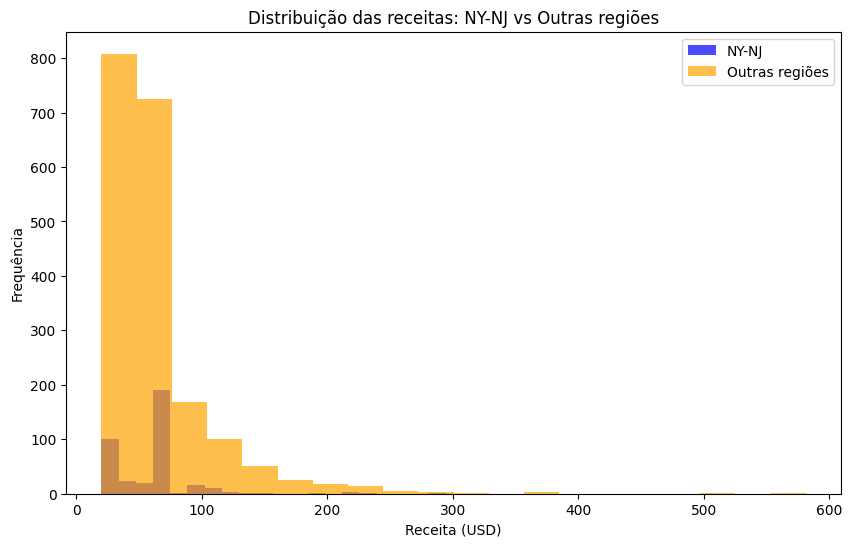

In [43]:
dados_com_cidade = monthly_usage.merge(users[['user_id', 'city']], on='user_id')
dados_com_cidade['eh_ny_nj'] = dados_com_cidade['city'].str.contains('New York-Newark-Jersey City')

receita_ny_nj = dados_com_cidade[dados_com_cidade['eh_ny_nj'] == True]['revenue']
receita_outras = dados_com_cidade[dados_com_cidade['eh_ny_nj'] == False]['revenue']
print('Receita média NY-NJ:', receita_ny_nj.mean())
print('Receita média outras regiões:', receita_outras.mean())
print('H0: Receitas são iguais')
print('H1: Receitas são diferentes')
var1 = receita_ny_nj.var()
var2 = receita_outras.var()
print('Variância NY-NJ:', var1)
print('Variância outras:', var2)

resultado = st.ttest_ind(receita_ny_nj, receita_outras)
print('p-value:', resultado.pvalue)
if resultado.pvalue < 0.05:
    print('Rejeitamos H0: há diferença')
else:
    print('Não rejeitamos H0: não há diferença')

plt.figure(figsize=(10,6))
plt.hist(receita_ny_nj, bins=20, alpha=0.7, label='NY-NJ', color='blue')
plt.hist(receita_outras, bins=20, alpha=0.7, label='Outras regiões', color='orange')
plt.title('Distribuição das receitas: NY-NJ vs Outras regiões')
plt.xlabel('Receita (USD)')
plt.ylabel('Frequência')
plt.legend()
plt.show()


## Conclusão geral

Liste suas conclusões importantes nesta seção final, certifique-se de que elas cobrem todas as decisões (suposições) importantes que você tomou e que levaram à maneira como você processou e analisou os dados.

Chamadas: médias praticamente iguais (Surf ~412 vs Ultimate ~410 min) são bem parecidas.
Mensagens: Ultimate um pouco maior (média ~46 vs ~40) pequena diferença uma da outra.
Internet: Ultimate um pouco maior (média ~17.2k MB vs ~16.7k MB) diferença pequena.
Receita: Ultimate maior (mediana 70 vs ~36.8 no Surf) e o teste t deu p-value. extremamente baixo, então diferença é bastante significativa.
Receita média de NY-NJ são um pouco menores do que as outras regiões (média NY-NJ: ~$55.76 vs Outras Regiões ~ $63.37 ). 
Conclusão do projeto: Tive um pouco de dor de cabeça para lembrar de algumas coisas bem especificas mas fui relendo meu caderno de anotacões e acabou dando tudo certo.
Usamos: groupby, reset.index, count, merge, pivot, hist agg, pvalue e ttest